# Classification Theory

## Overview

In classification problems, the goal is to predict the most likely class that any observation comes from, out of some $K$ possible classes. This is different from regresion problems, where we want to model some quantitative response $Y$ - here our "response" is the class, a qualitative variable.

There are two main ways classification is carried out:
* we can model the probabilities of a given observation coming from each of the $K$ possible classes through some discriminant functions, or
* we can model the boundaries between classes and directly verify which class our observation comes from.

Examples of the first approach include indicator matrix regression and linear discriminant regression (LDA). Examples of the second approach include logistic regression and separating hyperplanes.

## Indicator matrix regression

In indicator matrix regression still collect $n$ sets of observations of $p$ quantitative variables $X_1, \dots, X_p$, and arrange them in an $n\times p$ data matrix $\mathbf{X}$. The difference is that now, we need to keep track of $K$ response variables $Y_1, \dots, Y_K$. For any observation, if it comes from class $k$, then $Y_k = 1$ and $Y_j = 0$ for all $j\neq k$. These response variables therefore "indicate" which class an observation comes from, so we call them indicaor variables.

For each indicator variable $Y_j$, we keep track of the $n$ dimensional vector $\mathbf{y_j}$ containing the values of $Y_j$ for each of the $n$ observations. Then we perform $K$ separate linear regressions, one for each of $\mathbf{y}_j$ on the data $\mathbf{X}$, obtaining $K$ sets of coefficients $\hat{\beta}_1, \dots, \hat{\beta}_K$. Our model will then be of the form

$$\hat{y}_j = x^T \hat{\beta}_j \quad \quad j \in [1, K]$$

These are the $K$ discriminant functions modelling some measure of the probabilities for any observation of $X$ coming from each of the $K$ classes. It is more often to denote them by $\hat{\delta}_j(x) = x^T \hat{\beta}_j$, where $\hat{\delta}_j(x)$ is the discriminant function for the $j$-th class. 

We often combine the $K$ response vectors $\mathbf{y}_1, \dots, \mathbf{y}_K$ into a single $n\times K$ indicator matrix $\mathbf{Y} = (\mathbf{y}_1, \dots, \mathbf{y}_K)$, and combine the $K$ sets of coefficients $\hat{\beta}_1, \dots, \hat{\beta}_K$ into a single $p\times K$ matrix of coefficients $\hat{\mathbf{B}} = (\hat{\beta}_1, \dots, \hat{\beta}_K)$. Then we can write

$$\hat{\mathbf{B}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}$$
$$\hat{\mathbf{Y}} = \mathbf{X}\hat{\mathbf{B}} = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y} = \mathbf{H}\mathbf{Y}$$

where each row of $\hat{\mathbf{Y}}$ contains the fitted values of the $K$ discriminant functions, evaluated for the particular set of observations $x$ corresponding to that row.

For any observation $x$, the vector of all $K$ discriminant functions is given by

$$\hat{\delta}(x)^T = (\hat{\delta}_1(x), \dots, \hat{\delta}_K(x)) = x^T\hat{\mathbf{B}}$$

It turns out that if we include the constant variable, $X_1 = 1$ in our regression, then the sum of all discriminant functions for any given observation $x$ will always equal $1$. For more compact notation, denote the $m$-dimensional vector of all $1$'s by $\mathbf{1}_m$. We make the following observations:

* The sum of elements of a $m$-dimensional vector $\mathbf{v}$ is given by $\mathbf{v}^T \mathbf{1}_m$.
* Since each row of $\mathbf{Y}$ contains exactly one $1$ and all other entries are $0$'s, then $\mathbf{Y}\mathbf{1}_K = \mathbf{1}_n$.
* If we let the first variable $X_1$ be the constant variable $1$, then the leftmost column of $\mathbf{X}$ is precisely $\mathbf{1}_n$. For this reason, the leftmost column of $\mathbf{X}^T \mathbf{X}$ is identical to $\mathbf{X}^T \mathbf{1}_n$.
* Since the leftmost column of $\mathbf{X}^T \mathbf{X}$ is identical to $\mathbf{X}^T \mathbf{1}_n$, then $(\mathbf{X}^T \mathbf{X})^{-1} (\mathbf{X}^T \mathbf{1}_n)$ is identical to the leftmost column of $(\mathbf{X}^T \mathbf{X})^{-1} (\mathbf{X}^T \mathbf{X}) = \mathbf{I}$, which is just the $n$-dimensional vector $\mathbf{v}_1=(1, 0, \dots, 0)^T$.

Therefore, the sum of all discriminant functions $\hat{\delta}_1, \dots, \hat{\delta}_K$ is given by

$$\hat{\delta}(x)^T \mathbf{1}_K = x^T \hat{\mathbf{B}} \mathbf{1}_K = x^T (\mathbf{X}^T \mathbf{X})^{-1}\mathbf{X}^T \mathbf{Y} \mathbf{1}_K = x^T (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{1}_n = x^T \mathbf{v}_1 = (x_1)(1) = 1$$

## Linear Discriminant Analysis

Although indicator matrix regression is simple enough, it feels overly naive since it neglects how observations are distributed within each class. Linear discriminant analysis (LDA) resolves this issue.

### The Shape of Data

LDA can be understood much more intuitively by considering a geometric interpretation. Given $n$ observations of $p$ predictor variables, we can plot these $n$ observations in a $p$-dimensional vector space, called a sample space or an observation space.

This is in contrast to linear regression, where we plotted the $p$ vectors of values in a $n$-dimensional space. In linear regression, we were trying to find a linear combination of the variables $X_1, \dots, X_p$ to model $Y$, and hence we looked at the $p$ vectors in an $n$-dimensional feature space.

When we plot our $n$ observations in the $p$-dimensional sample space, we can see that the points form some sort of "cloud" around some mean, called the centroid of our data. We can approximate the shape of the data cloud by using an ellipse (in 2D) or ellipsoid (in general number of dimensions).

In the code below, we generate $100$ sets of observations of two variables $X_1, X_2$ and produced a scatter plot. We also plotted the data centroid, the ellipse which approximates the shape of the data cloud, and the axes of this ellipse.

Centroid: (2.876, 1.813)
1st principal component: [ 0.925  0.381]   Standard deviation: 2.233
2nd principal component: [-0.381  0.925]   Standard deviation: 1.403


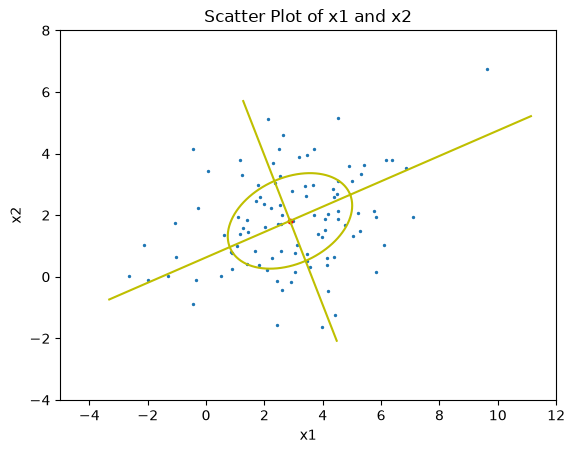

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, sign=' ')

rng = np.random.default_rng(seed=3)

N_OBS = 100

x1 = rng.normal(loc=3, scale=2, size=N_OBS)
x2 = 0.2 * x1 + rng.normal(loc=1, scale=1.5, size=N_OBS)

plt.scatter(x1, x2, s=2)    # Scatter plot of data points
plt.xlim([-5, 12])
plt.ylim([-4, 8])

x1_mean = np.mean(x1)
x2_mean = np.mean(x2)

X_matrix = np.vstack((x1 - x1_mean, x2 - x2_mean))                  # Centred data matrix
eigenvalues, principal_axes = np.linalg.eig(X_matrix @ X_matrix.T)  # Diagonalising data matrix
standard_deviations = np.sqrt(eigenvalues / N_OBS)                  # Calculating standard deviations
diagonal = np.diag(standard_deviations)                             # Diagonal matrix of standard deviations

ellipse_x = np.cos(np.linspace(0, 2 * np.pi, 100))
ellipse_y = np.sin(np.linspace(0, 2 * np.pi, 100))
ellipse_points = np.vstack((ellipse_x, ellipse_y))
ellipse_points_transformed = principal_axes @ diagonal @ ellipse_points

# Ellipse
plt.plot(ellipse_points_transformed[0,:] + x1_mean, ellipse_points_transformed[1,:] + x2_mean, c='y')

axis_x = np.linspace(-3, 4, 100)
horizontal_axis_points_transformed = principal_axes @ diagonal @ np.vstack((axis_x, np.zeros(100)))
axis_y = np.linspace(-3, 3, 100)
vertical_axis_points_transformed = principal_axes @ diagonal @ np.vstack((np.zeros(100), axis_y))

# Principal Axes
plt.plot(horizontal_axis_points_transformed[0,:] + x1_mean, horizontal_axis_points_transformed[1,:] + x2_mean, c='y')
plt.plot(vertical_axis_points_transformed[0,:] + x1_mean, vertical_axis_points_transformed[1,:] + x2_mean, c='y')

plt.scatter([x1_mean], [x2_mean], s=10, color='r')      # Centroid

print(f'Centroid: ({x1_mean:.3f}, {x2_mean:.3f})')
print(f'1st principal component: {principal_axes[:,0]}   Standard deviation: {standard_deviations[0]:.3f}')
print(f'2nd principal component: {principal_axes[:,1]}   Standard deviation: {standard_deviations[1]:.3f}')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Scatter Plot of x1 and x2');

### Principal Axes

In the scatter plot above, the ellipse approximating the data shape is drawn in a very precise manner. A unit circle is first drawn centred at the data centroid, then it is scaled along the axial directions by specific amounts to become an ellipse, followed by a rotation to "match" the scatter plot's distribution of points. How is this rotation, and the scales by which to stretch the axes, decided?

Visually, it seems that the axes of the ellipse correspond to the directions in which the data is most spread out. This is the key idea of Principal Components Analysis (PCA).

The axes of the final ellipse are known as the principal axes of the data. The first principal axis is defined by the direction in which the data shows the greatest variance. To calculate variance along a direction, all the data points are projected onto that direction, and the length of projection is recorded for each point. The variance in these lengths of projection is the variance along that direction.

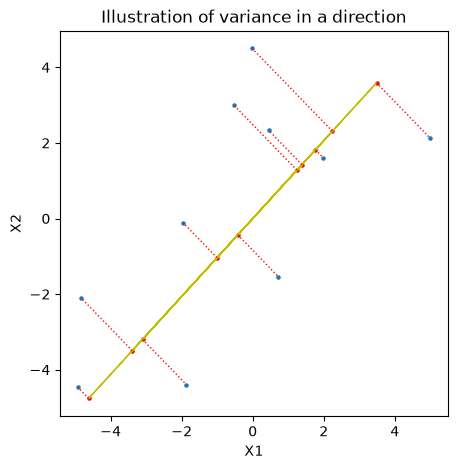

In [2]:
rng = np.random.default_rng(seed=4)

x = rng.normal(loc=0, scale=3, size=10)
y = 0.3 * x + rng.normal(loc=0, scale=2, size=10)

plt.subplots(figsize=(5,5))
plt.scatter(x, y, s=5)

X_matrix = np.vstack((x, y))
eigenvalues, eigenvectors = np.linalg.eig(X_matrix @ X_matrix.T)
direction = eigenvectors[:,1]

projections = direction @ X_matrix

x_proj = direction[0] * projections
y_proj = direction[1] * projections

plt.plot(x_proj, y_proj, color='y', lw=1)
plt.scatter(x_proj, y_proj, s=5, color='r')
for i in range(10):
    plt.plot([x_proj[i], x[i]], [y_proj[i], y[i]], lw=1, ls=':', color='r')

plt.xlabel('X1')
plt.ylabel('X2')

plt.title('Illustration of variance in a direction');

Before proceeding any further, we will "centre" our data. This means that for every column of $\mathbf{X}$, we compute the mean value of that column, and subtract off this mean from each value in that column. The resultant matrix will have $0$ column means for all $p$ columns. We will take $\mathbf{X}$ to be a centred data matrix from here onwards.

The vector of lengths of projections for the data points onto some direction $v$, where $v$ is a $p$-dimensional unit vector, is just $\mathbf{X} v$. Since $\mathbf{X}$ has zero column means for all $p$ column, then $\mathbf{X}^T\mathbf{1}_n = \mathbf{0}_p$ and so the mean of the values in $\mathbf{X}v$ is $(\mathbf{X}v)^T\mathbf{1}_n = v^T \mathbf{X}^T \mathbf{1}_n = v^T \mathbf{0}_p = 0$. Therefore, the variance of the values of $\mathbf{X}v$ is just the average of their squares, given by

$$\frac{1}{n}\lVert\mathbf{X}v\rVert^2 = \frac{1}{n}v^T \mathbf{X}^T \mathbf{X} v$$

Since $\mathbf{X}^T\mathbf{X}$ is a symmetric $p\times p$ matrix, it can be diagonalised: $\mathbf{X}^T\mathbf{X} = \mathbf{U}\mathbf{D}\mathbf{U}^T$ for some orthogonal $p\times p$ matrix $\mathbf{U}$ whose columns are eigenvectors of $\mathbf{X}^T\mathbf{X}$, and diagonal $p\times p$ matrix $\mathbf{D}$ whose diagonal entries are the eigenvalues of those eigenvectors (columns of $\mathbf{U}$). Then the variance of the values in $\mathbf{X}v$ is

$$\text{var}(\mathbf{X}v) = \frac{1}{n}v^T \mathbf{X}^T \mathbf{X}v = \frac{1}{n} v^T \mathbf{U}\mathbf{D}\mathbf{U}^T v = \frac{1}{n} u^T\mathbf{D}u$$

where $u=\mathbf{U}^T v$ is also a unit vector. As $v$ varies across all unit vectors, $u$ also varies across all unit vectors. WLOG we arrange diagonal entries of $\mathbf{D}$ by $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_p$, then

$$\frac{1}{n} u^T \mathbf{D}u = \frac{1}{n}\sum_{i=1}^{p}{\lambda_i u_i^2} \in [\lambda_p \lVert u \rVert^2, \lambda_1 \lVert u \rVert^2] = [\lambda_p, \lambda_1]$$

The eigenvalues are all positive since if $\lambda$ is the eigenvalue of an eigenvector $v$ of $\mathbf{X}^T \mathbf{X}$ then 

$$\lambda \lVert v\rVert^2 = \lambda v^T v = v^T (\lambda v) = v^T (\mathbf{X}^T \mathbf{X} v) = (\mathbf{X} v)^T \mathbf{X}v = \lVert \mathbf{X} v \rVert^2 \quad \Longrightarrow \quad \lambda = \frac{\lvert \mathbf{X}v\rVert^2}{\lvert v \rVert^2} \ge 0$$

Hence, the maximum variance is attained at $\lambda_1 \lVert u \rVert^2 = \lambda_1$, by setting $u_1 = 1$ and $u_j = 0$ for all $j\neq 1$. This corresponds to

$$v = \mathbf{U} u = \mathbf{u}_1$$

which is the corresponding eigenvector of $\mathbf{X}^T\mathbf{X}$ with the largest eigenvalue.

Subsequent principal axes are defined by the direction orthogonal to all previous principal axes in which the data has the largest variance. Since the vectors of $\mathbf{U}$ are orthonormal, then we can inductively show that the $k$-th principal axis is obtained when $u_k = 1$ and $u_j = 0$ for all $j\neq k$, which corresponds to the eigenvector $\mathbf{u}_k$ with the $k$-th largest eigenvalue.

Therefore, the principal axes are the eigenvectors of $\mathbf{X}^T\mathbf{X}$, in decreasing order of eigenvalues.

Finally, notice that for a centred data matrix $\mathbf{X}$, the matrix $\frac{1}{n}\mathbf{X}^T\mathbf{X}$ is the sample covariance matrix, since

$$\left(\frac{1}{n}\mathbf{X}^T\mathbf{X}\right)_{kl} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{X}_{ik} \mathbf{X}_{il} = \text{cov}(\mathbf{x}_k, \mathbf{x}_l)$$

where $\mathbf{X}_{1j}, \mathbf{X}_{2j}, \dots, \mathbf{X}_{nj}$ have zero mean for each $j$ when $\mathbf{X}$ is centred.

### Creating the Ellipse

Recall that $\text{var}(\mathbf{X}v) = \frac{1}{n}u^T\mathbf{D}u$. For the $k$-th principal axis $v$, the corresponding vector $u$ is given by $u_k = 1$ and $u_j = 0$ for all $j\neq k$, so 

$$\text{var}(\mathbf{X}v) = \frac{1}{n}u^T \mathbf{D} u = \frac{\lambda_k}{n}$$

Hence, the standard errors along the $k$-th principal axis is equal to $\frac{\sqrt{\lambda_k}}{\sqrt{n}}$.

The ellipise is drawn along the principal axes, with axial lengths equal to $1$ standard error along those axes. Therefore, the required sequence of transformations from a unit circle to the ellipse is:
1. scaling along the $k$-th axis by a factor of $\frac{\sqrt{\lambda_k}}{\sqrt{n}}$, then
2. rotating so that the $k$-th axis goes to the column vector $\mathbf{u}_k$ with the $k$-th largest eigenvalue.

The matrix representing this transformation sequence is given by
$$\frac{1}{\sqrt{n}}\mathbf{U}\mathbf{D}^{1/2}$$

where $\mathbf{D}^{1/2}$ for any diagonal matrix $\mathbf{D}$ is calculated by taking the square root for each of the diagonal entries.

### Idea behind LDA

The main idea behind LDA is that the scatter plot of observations should have $K$ clusters, one for each class. Then for any observation $x$, we can classify it to the class whose cluster's centroid is closest to $x$, where for some notion of "closeness".

In the code below, we have generated $3$ classes of observations, $20$ from each class.

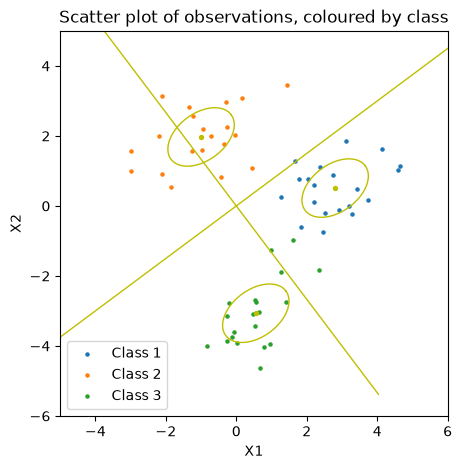

In [3]:
rng = np.random.default_rng(seed=5)

m = np.array([[3, 1], [-1, 2], [1, -3]])

x1_clusters = np.zeros((3, 20))
x2_clusters = np.zeros((3, 20))

plt.subplots(figsize=(5,5))

for i in range(3):
    x1 = rng.normal(loc=0, scale=1, size=20)
    x1_clusters[i] = x1 + m[i][0]
    x2_clusters[i] = rng.normal(loc=0, scale=1, size=20) + 0.2 * x1 + m[i][1]
    plt.scatter(x1_clusters[i], x2_clusters[i], s=5, label=f'Class {i + 1}')

X_matrix = np.vstack((
    np.hstack(tuple(x1_clusters[i,:] for i in range(3))),
    np.hstack(tuple(x2_clusters[i,:] for i in range(3)))
))

means_x1 = [np.mean(x1_clusters[i]) for i in range(3)]
means_x2 = [np.mean(x2_clusters[i]) for i in range(3)]

X_pooled = np.vstack((
    np.hstack(tuple(x1_clusters[i,:] - means_x1[i] for i in range(3))),
    np.hstack(tuple(x2_clusters[i,:] - means_x2[i] for i in range(3)))
))

eigenvalues, eigenvectors = np.linalg.eig(X_pooled @ X_pooled.T)
diagonal = np.diag(np.sqrt(eigenvalues / 60))
transform = eigenvectors @ diagonal

circle_x = np.cos(np.linspace(0, 2 * np.pi, 100))
circle_y = np.sin(np.linspace(0, 2 * np.pi, 100))

circle = np.vstack((circle_x, circle_y))
transformed_circle = transform @ circle

ellipse_x = transformed_circle[0,:]
ellipse_y = transformed_circle[1,:]

horizontal = np.vstack((np.linspace(-10, 10, 100), np.zeros(100)))
transformed_horizontal = transform @ horizontal
plt.plot(transformed_horizontal[0,:], transformed_horizontal[1,:], lw=1, color='y')

vertical = np.vstack((np.zeros(100), np.linspace(-10, 10, 100)))
transformed_vertical = transform @ vertical
plt.plot(transformed_vertical[0,:], transformed_vertical[1,:], lw=1, color='y')

for i in range(3):
    plt.plot(ellipse_x + means_x1[i], ellipse_y + means_x2[i], lw=1, color='y')

plt.xlim((-5, 6))
plt.ylim((-6, 5))

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Scatter plot of observations, coloured by class')

plt.scatter(means_x1, means_x2, s=8, color='y')
plt.legend();

Under LDA, the shapes of the ellipses for every cluster are chosen to be the same, and yet fit the overall data the best. This is done by computing the shape of the ellipse that would be formed for the full data set of $60$ data points, if the $3$ clusters were all moved so that their centroids lie at the origin. 

The pooled covariance matrix describing the shape of the common ellipse would be obtained by first subtracting each observation $x_i$ of $\mathbf{X}$ by the centroid $\hat{\mu}_{y_i}$ of the class $y_i$ that $x_i$ comes from, to obtain the matrix $\mathbf{W}$. Then the pooled covariance matrix is

$$\frac{1}{n}\mathbf{W}^T\mathbf{W} = \frac{1}{n}\sum_{i=1}^{n}{(x_i - \hat{\mu}_{y_i})(x_i - \hat{\mu}_{y_i})^T}$$

The diagram below illustrates this shift:

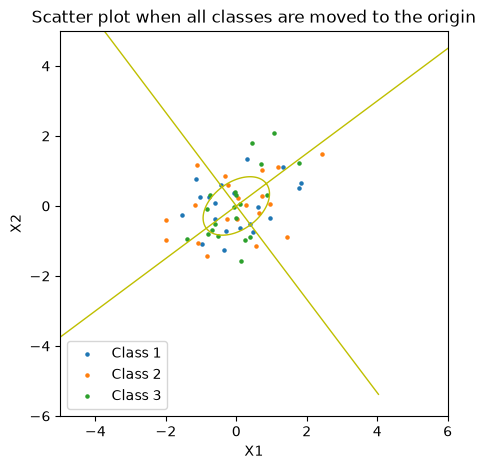

In [4]:
plt.subplots(figsize=(5,5))

for i in range(3):
    plt.scatter(x1_clusters[i] - means_x1[i], x2_clusters[i] - means_x2[i], s=5, label=f'Class {i + 1}')

plt.plot(transformed_horizontal[0,:], transformed_horizontal[1,:], lw=1, color='y')
plt.plot(transformed_vertical[0,:], transformed_vertical[1,:], lw=1, color='y')
plt.plot(ellipse_x, ellipse_y, lw=1, color='y')

plt.xlim((-5, 6))
plt.ylim((-6, 5))

plt.legend()

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Scatter plot when all classes are moved to the origin');

As mentioned earlier, we classify data points to the class whose centroid is the "closest", for some notion of "closeness" that cannot be the naive Euclidean distance.

The following diagram illustrates why we cannot use Euclidean distances. If we used Euclidean distances, the red point would be closer to the class 2 centroid, and so we would have to classify it under class 2. However, it lies within the ellipse for class 1 but not class 2.

![Why Euclidean distances fail](visuals/lda-distance.png)

The underlying distribution for each class might cause variances in certain directions to be much lower than in other directions, so distances in different directions should be viewed differently. More specifically, $\lambda_k$ units in the $k$-th principal component should be viewed equally across all $k$. Such a notion of distance is known as the Mahalanobis distance.

To resolve this issue, recall the matrix $\frac{1}{\sqrt{n}}\mathbf{U}\mathbf{D}^{1/2}$ which transformed a unit circle to the ellipse. Its inverse $\sqrt{n}\mathbf{D}^{-1/2}\mathbf{U}^T$ will transform the ellipse back to a unit circle. (Since we are considering the common ellipse, the diagonalisation $\mathbf{U}\mathbf{D}\mathbf{U}^T$ is that of $\mathbf{W}^T\mathbf{W}$ where $\mathbf{W}$ is the resultant matrix when each row of $\mathbf{X}$ is subtracted by the centroid of the class that row of observations comes from.)

Hence, we can transform all the points in the sample space by this matrix, thereby sphering the data. Then the Euclidean distance between two points after the transformation will be equal to the Mahalanobis distance before the transformation.

For two points $u, v$ in the original sample space before the transformation, their squared Euclidean distance after the transformation will be given by 

$$\lVert \sqrt{n}\mathbf{D}^{-1/2}\mathbf{U}^T (u-v)\rVert^2 = (u-v)^T \left(\sqrt{n}\mathbf{D}^{-1/2}\mathbf{U}^T\right)^T \left(\sqrt{n}\mathbf{D}^{-1/2}\mathbf{U}^T\right) (u-v) $$

Given that $\frac{1}{n}\mathbf{W}^T \mathbf{W}$ is the pooled covariance matrix $\mathbf{\Sigma}$, we have

$$\mathbf{\Sigma} = \frac{1}{n} \mathbf{U}\mathbf{D}\mathbf{U}^T = \left(\frac{1}{\sqrt{n}}\mathbf{U}\mathbf{D}^{1/2}\right) \left(\frac{1}{\sqrt{n}}\mathbf{U}\mathbf{D}^{1/2}\right)^T $$

and so

$$\mathbf{\Sigma}^{-1} = \left(\sqrt{n}\mathbf{D}^{-1/2}\mathbf{U}^T\right)^T \left(\sqrt{n}\mathbf{D}^{-1/2}\mathbf{U}^T\right)$$

Hence, the Mahalanobis distance between any points $u, v$ is given by

$$(u-v)^T \left(\sqrt{n}\mathbf{D}^{-1/2}\mathbf{U}^T\right)^T \left(\sqrt{n}\mathbf{D}^{-1/2}\mathbf{U}^T\right) (u-v) = (u-v)^T \mathbf{\Sigma}^{-1} (u-v)$$

This last expression $(u-v)^T\mathbf{\Sigma}^{-1}(u-v)$ is worth remembering.

### Derivation of LDA

LDA is fundamentally a form of Bayesian inference. Under LDA, the distributions of predictors $(X_1, \dots, X_p)$ in each class $k$ are modelled by a multivariate normal distribution. For the $k$-th class, we model the distribution by 

$$X \sim \text{MVN}(\mu_k, \mathbf{\Sigma})$$

where the $k$ classes have their own within-class means $\mu_1, \dots, \mu_K$, but share a pooled covariance matrix $\mathbf{\Sigma}$.

Each class is first given a prior probability $\pi_1, \dots, \pi_K$. This is the probability that any observation comes from each class if we know nothing about it. Upon observing its predictor values, we update the probabilities according to Bayes' rule:

$$\mathbb{P}(k|X) = \frac{\mathbb{P}(X|k)\mathbb{P}(k)}{\mathbb{P}(X)} \propto {\mathbb{P}(X|k)\mathbb{P}(k)}$$

Substituting the multivariate normal distributions, as well as the prior probabilities, we get

$$\mathbb{P}(k|X) \propto \frac{1}{(2\pi)^{p/2}|\mathbf{\Sigma}|}\text{exp}\left(-\frac{1}{2}(X-\mu_k)\mathbf{\Sigma}^{-1}(X-\mu_k)\right) \cdot \pi_k $$

However, the true values of $\pi_k$, $\mu_k$, $\mathbf{\Sigma}$ are unknown. We must estimate these parameters using maximum likelihood estimation. Since the above formula is proportional to the likelihood of a single observation $X$ coming from class $k$, the likelihood of our data set is given by

$$\prod_{i=1}^{n}{\frac{1}{(2\pi)^{p/2}|\mathbf{\Sigma}|}\text{exp}\left(-\frac{1}{2}(x_i-\mu_{y_i})\mathbf{\Sigma}^{-1}(x_i-\mu_{y_i})\right) \cdot \pi_{y_i}}$$

where $y_i$ is the class that observation $x_i$ comes from. Taking logarithms and partial derivatives, we obtain the maximum likelihood estimates:

$$\hat{\pi}_k = \frac{n_k}{n} \quad \quad \hat{\mu}_k = \frac{1}{n_k}\sum_{y_i = k}{x_i} \quad \quad \hat{\mathbf{\Sigma}} = \frac{1}{n}\sum_{k=1}^{K}\sum_{y_i = k}{(x_i - \hat{\mu}_k)(x_i - \hat{\mu}_k)^T}$$

where $n_k$ is the number of observations in our data that comes from class $k$. 

[!CAUTION]
Take note that the maximum likelihood estimates for $\hat{\pi}_k$ and $\hat{\mu}_k$ also happen to be unbiased, but $\mathbf{\Sigma}$ with the coefficient $\frac{1}{n}$ as obtained from maximum likelihoods would be biased. To obtain an unbiased estimate, the denominator must be changed to $n-K$. If the sample sizes for each of the $K$ classes are identical, this has no effect on the decision boundaries.

Substituting these estimates, we will be able to calculate the posterior probabilities of any given observation $x$ being in each of the $K$ classes. For ease of comparison, we take their logarithms and eliminate any constants to form our discriminant functions:

$$\hat{\delta}_k(x) = -\frac{1}{2}(x-\hat{\mu}_k)^T \hat{\mathbf{\Sigma}}^{-1} (x-\hat{\mu}_k) + \log\hat{\pi}_k$$

[!CAUTION] Technically, the term $-\frac{1}{2}x^T\hat{\mathbf{\Sigma}}^{-1}x$ is constant across all discriminant functions, but we include it to get a nicer expression. If we were to remove it though, the resultant discriminant function will be linear in $x$, hence the name, "linear" discriminant analysis:

$$\hat{\delta}_k(x) = x^T \hat{\mathbf{\Sigma}}^{-1} \hat{\mu}_k - \frac{1}{2} \hat{\mu}_k^T \hat{\mathbf{\Sigma}}^{-1} \hat{\mu}_k + \log\hat{\pi}_k$$

The linear discriminant functions imply that the decision boundaries are straight lines.

Notice the original expression (with the $-\frac{1}{2}x^T\hat{\mathbf{\Sigma}}^{-1}x$ term) comprises the Mahalanobis distance from $x$ to $\hat{\mu}_k$ obtained in the earlier section, and some prior log likelihood $\log\hat{\pi}_k$. Hence, classification based on the Mahalanobis distance to the respective class centroids follows from assuming a multivariate normal distribution of observations.

In the code below, we write a function classifying observations into the $3$ classes using LDA. Since in our training data from earlier, the number of observations for each class is the same, we can ignore the $\log\hat{\pi}_k$ terms in the discriminant functions, and focus solely on the Mahalanobis distances when classifying.

In [5]:
Sigma = 1 / 60 * eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
Sigma_inv = 60 * eigenvectors @ np.diag(1 / eigenvalues) @ eigenvectors.T
mu = np.array([means_x1, means_x2])

def classify(x):
    delta = np.zeros(3)

    for i in range(3):
        delta[i] = (x.T @ Sigma_inv @ mu[:,i]) - ((1 / 2) * mu[:,i].T @ Sigma_inv @ mu[:,i]) + np.log(1 / 3)

    classification = np.argmax(delta)

    print(f'Discriminant functions:\n{delta}')
    print(f'Class: {classification + 1}')

    return classification

print(f'covariance:\n{Sigma}')
print(f'means:\n{mu.T}')
classify(np.array([1,2]))

covariance:
[[ 0.888  0.327]
 [ 0.327  0.697]]
means:
[[ 2.806  0.511]
 [-1.     1.971]
 [ 0.553 -3.065]]
Discriminant functions:
[ -4.082  -0.913 -19.146]
Class: 2


np.int64(1)

We can do the same classification by leveraging `sklearn`:

In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import pandas as pd

LDA_model = LDA(store_covariance=True)

X_train = pd.DataFrame(X_matrix.T)

y_numpy = np.hstack((np.full(20, 1), np.full(20, 2), np.full(20, 3))).T
y_train = pd.DataFrame(y_numpy)

fitted_LDA_model = LDA_model.fit(X_train, y_train)

print(f'sklearn LDA covariance:\n{fitted_LDA_model.covariance_}')
print(f'sklearn LDA means:\n{fitted_LDA_model.means_}')
print(f'sklearn LDA priors:\n{fitted_LDA_model.priors_}')

print(f'sklearn LDA discriminant functions:\n{fitted_LDA_model.decision_function([[1, 2]])}')
print(f'sklearn LDA prediction: {fitted_LDA_model.predict([[1,2]])}')

sklearn LDA covariance:
[[ 0.888  0.327]
 [ 0.327  0.697]]
sklearn LDA means:
[[ 2.806  0.511]
 [-1.     1.971]
 [ 0.553 -3.065]]
sklearn LDA priors:
[ 0.333  0.333  0.333]
sklearn LDA discriminant functions:
[[ -2.951   0.06  -17.262]]
sklearn LDA prediction: [ 2]


c:\Users\yxpeh\Projects\ISLP\ISLP\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### Dimension Reduction on Centroids (Fisher Projection)



Since all we care about is the Mahalanobis distance to the centroids of the $K$ classes, we can just keep track of the images of the $K$ centroids under the transformation $\sqrt{n}\mathbf{D}^{-1/2}\mathbf{U}^T$.

To preserve the original axes in $X_1, \dots, X_p$, after sphering we will undo the rotation so that the effect is just a scaling along the principal axes of the data. This is represented by the matrix $\sqrt{n}\mathbf{U}\mathbf{D}^{-1/2}\mathbf{U}^T = \hat{\mathbf{\Sigma}}^{-1/2}$. Under this transformation, the axes will change from $X = (X_1, \dots, X_p)^T$ to $X^* = \hat{\mathbf{\Sigma}}^{-1/2} X$

To visualise the images, we will need to further project the images onto a two-dimensional plane so that we can plot them. With a total of $K$ classes, the $K$ centroid images live in a $(K-1)$-dimensional subspace. How should we choose the plane on which to project the images? To spread out the centroid images as much as possible, we will pick the two orthogonal directions in which the variance in the centroids is the largest. We once again compute the principal axes, but of the centroids this time.

Let the $K$ untransformed centroids be represented by a $K\times p$ matrix $\mathbf{M}$. The transformed centroids can be represented by the $K\times p$ matrix $\mathbf{M}^{*}$ given by

$$\mathbf{M}^{*} = \mathbf{M}(\sqrt{n}\mathbf{U}\mathbf{D}^{-1/2}\mathbf{U}^T) = \mathbf{M}\hat{\mathbf{\Sigma}}^{-1/2}$$

We could find principal components by diagonalising ${\mathbf{M}^{*}}^T\mathbf{M}^{*}$, but this does not take into account the sample size of each class. Instead, we will diagonalise the between-class covariance matrix

$$\mathbf{B}^{*} = \sum_{k=1}^{K} \frac{n_k}{n}(\mu_k^* - \mu^*)(\mu_k^* - \mu^*)^T$$

where $\mu_k^*$ is the transformed centroid of the $k$-th class, and $\mu^*$ is the sample size-weighted centroid of the $K$ transformed centroids:

$$\mu^* = \sum_{k=1}^{K} \frac{n_k}{n}\mu_k^*$$

After diagonalising $\mathbf{B}^* = \mathbf{V}^{*}\mathbf{D}^{*}{\mathbf{V}^{*}}^T$, we pick the first two principal components $v^*_1, v^*_2$ with the largest eigenvalues $\lambda_1^*, \lambda_2^*$. Therefore, the axes of the projection will be ${v^*_1}^T X^*$ and ${v^*_2}^T X^*$. In terms of the original predictors $X$, the axes will be $v_1^T X$ and $v_2^T X$, where $v_i^T = {v^*_i}^T \hat{\mathbf{\Sigma}}^{-1/2}$.

Estimated Class Priors:
[ 0.2   0.15  0.18  0.25  0.22]
Estimated Class Means:
[[ 2.927  3.139  5.238]
 [ 4.791  2.235  8.223]
 [-0.834  1.33  -2.067]
 [ 1.634  0.546  0.986]
 [ 6.111 -0.423  4.154]]
Estimated Pooled Covariance:
[[ 4.121  0.367  0.378]
 [ 0.367  1.833 -0.013]
 [ 0.378 -0.013  1.049]]


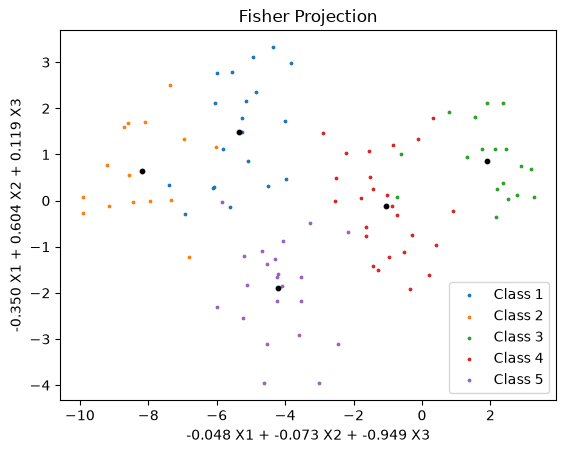

In [7]:
K = 5
P = 3
N_k = np.array([20, 15, 18, 25, 22])
MU_k = np.array([[2, 3, 5],
                 [5, 2, 8],
                 [0, 1, -2],
                 [1, 0, 1],
                 [6, -1, 4]])

rng = np.random.default_rng(seed=6)

X = [np.zeros((N_k[i], P)) for i in range(K)]

for i in range(K):
    X[i][:,0] = rng.normal(MU_k[i][0], 2, N_k[i])
    X[i][:,1] = rng.normal(MU_k[i][1], 1.5, N_k[i]) + 0.1 * X[i][:,0]
    X[i][:,2] = rng.normal(MU_k[i][2], 1, N_k[i]) + 0.05 * X[i][:,0] + 0.02 * X[i][:,1]

mu_hat_k = np.array([np.mean(X[i], axis=0) for i in range(K)])
N = np.sum(N_k)
pi_hat_k = np.array([N_k[i] / N for i in range(K)])

W = np.vstack([X[i] - mu_hat_k[i] for i in range(K)])
Sigma_hat = (1 / N) * (W.T @ W)

print(f'Estimated Class Priors:\n{pi_hat_k}')
print(f'Estimated Class Means:\n{mu_hat_k}')
print(f'Estimated Pooled Covariance:\n{Sigma_hat}')

lambdas, U = np.linalg.eig(Sigma_hat)
D_inv_sqrt = np.diag(1 / np.sqrt(lambdas))
Sigma_hat_inv_sqrt = U @ D_inv_sqrt @ U.T

M_star = mu_hat_k @ Sigma_hat_inv_sqrt
mu_star = sum((N_k[i] / N) * M_star[i,:] for i in range(K))
B_star = sum((N_k[i] / N) * (np.outer((M_star[i,:] - mu_star),(M_star[i,:] - mu_star))) for i in range(K))

lambdas_star, V_star = np.linalg.eig(B_star)

v_star_1 = V_star[:,np.argsort(lambdas_star)[-1]]
v_star_2 = V_star[:,np.argsort(lambdas_star)[-2]]

v_1 = Sigma_hat_inv_sqrt @ v_star_1
v_2 = Sigma_hat_inv_sqrt @ v_star_2

X_star = [X[i] @ Sigma_hat_inv_sqrt for i in range(K)]
X_star_v_1 = [X_star[i] @ v_star_1 for i in range(K)]
X_star_v_2 = [X_star[i] @ v_star_2 for i in range(K)]

M_star_v_1 = M_star @ v_star_1
M_star_v_2 = M_star @ v_star_2

for i in range(K):
    plt.scatter(X_star_v_1[i], X_star_v_2[i], s=3, label=f'Class {i + 1}')

plt.scatter(M_star_v_1, M_star_v_2, s=10, color='k')
plt.xlabel(f'{v_1[0]:.3f} X1 + {v_1[1]:.3f} X2 + {v_1[2]:.3f} X3')
plt.ylabel(f'{v_2[0]:.3f} X1 + {v_2[1]:.3f} X2 + {v_2[2]:.3f} X3')

plt.title('Fisher Projection')

plt.legend(loc='lower right');

## Logistic Regression

Logistic regression arises from trying to use a linear combination of the predictor variables to model the probabilities of an observation $x$ belonging to each of the $K$ classes, such that the probabilities are positive and sum to $1$. 

### Formulating the Model

A linear expression $\beta_1 X_1 + \dots + \beta_p X_p$ does not necessarily give a positive value. To force a positive value, we take the exponential function $e^{\beta_1 X_1 + \dots + \beta_p X_p} = e^{X^T \beta}$.

For each class $k=1, \dots, K$, we have a separate vector of coefficients $\beta$ - label them by $\beta_k$. In order for the $K$ expressions to sum to $1$, we normalise them, obtaining the model

$$\mathbb{P}(Y=k) = \frac{e^{X^T \beta_k}}{\sum_{i=1}^{K}e^{X^T\beta_i}}$$

where here $Y$ is the class that observation $X$ comes from.

This actually uses more parameters than we need, since the last probability $\mathbb{P}(Y=K)$ must be $1$ minus the previous $K-1$ probabilities. As such, we can simplify the model to

$$\mathbb{P}(Y=k) = \frac{e^{X^T \beta_k}}{1 + \sum_{i=1}^{K-1}e^{X^T\beta_i}} \quad \quad \quad \forall k=1, \dots, K-1$$
$$\mathbb{P}(Y=K) = \frac{1}{1 + \sum_{i=1}^{K-1}e^{ X^T \beta_i}}$$

### Fitting the Model

The $(K-1)p$ parameters $\beta_1, \beta_2, \dots, \beta_p$ are fit by maximum likelihoods. 

For an observation $x$ from class $k$, we calculate its likelihood $\mathbb{P}(Y=k|X=x)$ under the model with parameters $\beta$, and multiply all the likelihoods for the $n$ data points to compute the likelihood of our training data for any choice of parameters $\beta$. Then the parameters $\beta$ are chosen to maximise this likelihood. Almost always, we would take the logarithm of this likelihood, and maximise the log-likelihood instead.

For the case with $K=2$ classes, we only have $1$ vector of coefficients $\beta$. We can employ a $0$-$1$ coding of the classes that each observation comes from. If an observation comes from class $1$, we code it $y=1$, and if it comes from class $2$, we code it $y=0$. Then the log-likelihood of a data point $(x,y)$ is given by

$$\ell = y\log\left(\frac{e^{x^T \beta}}{1 + e^{x^T \beta}}\right) + (1-y)\log\left(\frac{1}{1+e^{ x^T\beta}}\right) = y(x^T \beta) - \log(1 + e^{x^T \beta}) $$

The log-likelihood of a the entire set of observations $(x_i, y_i)$ will then be

$$\ell = \sum_{i=1}^{n}\left\{y_i (x_i^T\beta) - \log(1+ e^{x_i^T \beta})\right\}$$

Taking derivatives with respect to $\beta$, we get

$$\frac{\partial \ell}{\partial \beta} = \sum_{i=1}^{n}\left\{y_i x_i - \frac{x_i e^{x_i^T \beta}}{1 + e^{x_i^T\beta}}\right\} = \sum_{i=1}^{n}x_i(y_i - p(x_i;\beta))$$

where $p(x;\beta)$ denotes the probability of the observation $x$ being from class $1$ under the model with parameters $\beta$. 
To maximise log-likelihood, we set the derivatives to $0$. These "score" equations are:

$$\sum_{i=1}^{n}x_i(y_i - p(x_i;\beta)) = \mathbf{0}_p$$

which are $p$ equations non-linear in $\beta$. Unfortunately, this is difficult to solve analytically, so in practice we use the Newton-Raphson algorithm to perform gradient-descent on $\beta$. This algorithm requires the second-derivative matrix

$$\frac{\partial^2 \ell}{\partial \beta \partial \beta^T} = -\sum_{i=1}^{n}x_i \frac{x_i^T e^{x_i^T \beta}}{(1+e^{x_i^T\beta})^2} = -\sum_{i=1}^{n}x_i x_i^T p(x_i; \beta) (1-p(x_i; \beta))$$

Under the Newton-Raphson algorithm, we start with a initial guess for $\beta$ denoted $\beta^{(0)}$, and maximise the log-likelihood. On the $i$-th iteration of the algorithm, we update our guess to

$$\beta^{(i)} = \beta^{(i-1)} + \left(\frac{\partial^2 \ell}{\partial \beta \partial \beta^T}\right)^{-1} \frac{\partial\ell}{\partial\beta}$$

where the score vector of derivatives, and the second-derivative matrix are both evaluated using $\beta^{(i-1)}$. We can write this in matrix notation. Under the model with parameters $\beta$, let 
* $\mathbf{y}$ denote the vector the class codings $(y_1, \dots, y_n)^T$,
* $\mathbf{p}$ denote the $n$-dimensional vector of probabilities $p(x_i; \beta)$,
* $\mathbf{W}$ denote the $n\times n$ diagonal matrix with diagonal entries $p(x_i; \beta)(1-p(x_i; \beta))$,
* $\mathbf{X}$ denote the $n\times p$ data matrix as per usual.

Then

$$\frac{\partial \ell}{\partial \beta} = \sum_{i=1}^{n}x_i(y_i - p(x_i;\beta)) = \mathbf{X}^T(\mathbf{y}-\mathbf{p})$$

$$\frac{\partial^2 \ell}{\partial \beta \partial \beta^T} =-\sum_{i=1}^{n}x_i x_i^T p(x_i; \beta) (1-p(x_i; \beta)) = -\mathbf{X}^T\mathbf{W}\mathbf{X}$$

and so our Newton-Raphson algorithm is

$$
\begin{aligned}
\beta^{(i)} &=\beta^{(i-1)} -(\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T(\mathbf{y}-\mathbf{p}) \\&= (\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T\mathbf{W}(\mathbf{X}\beta^{(i-1)} - \mathbf{W}^{-1}(\mathbf{y}-\mathbf{p}))
\\&= (\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T\mathbf{W}\mathbf{z}
\end{aligned}$$

where $\mathbf{z} = \mathbf{X}\beta^{(i-1)} - \mathbf{W}^{-1}(\mathbf{y}-\mathbf{p})$. This can be seen as performing a weighted least squares regression of the response $\mathbf{z}$ on $\mathbf{X}$ with weights $\mathbf{W}$ at each iteration.

Therefore, the maximum likelihood estimate $\hat{\beta}$ satisfies a self-consistency relationship - they are the coefficients of a weighted least squares fit, where the responses are

$$z_i = x_i^T\hat{\beta}-\frac{y_i-\hat{p}_i}{\hat{p}_i(1-\hat{p}_i)} \quad \quad \quad \text{where } \hat{p}_i = \frac{e^{x_i^T\hat{\beta}}}{1 + e^{x_i^T\hat{\beta}}}$$

and weights are

$$w_i = \hat{p}_i(1 - \hat{p}_i)$$

In the above mathematical framework, the fitting method by Newton's method requires a Hessian matrix which can be quite computationally intensive. In the code below, we attempt to fit a logistic regression model by using a simpler gradient ascent algorithm with some constant learning rate $\alpha$:

$$\beta^{(i+1)} = \beta^{(i)} + \alpha \frac{\partial\ell}{\partial \beta} $$

Substituting $\frac{\partial\ell}{\partial\beta}$ we get

$$\beta^{(i+1)} = \beta^{(i)} + \alpha \mathbf{X}^T (\mathbf{y} - \mathbf{p})$$

We generate our observations $X$ of $5$ predictor variables from the true distributions

$$X \sim \text{N}(\mu_1, \mathbf{A}\mathbf{A}^T) \quad \text{for }Y = 1 \quad \quad \quad \quad X \sim \text{N}(\mu_0, \mathbf{A}\mathbf{A}^T) \quad \text{for }Y = 0$$

by generating $Z \sim \text{N}(\mathbf{0}, \mathbf{I})$ and calculating $X = \mathbf{A}Z + \mu_i$.

In [8]:
import numpy as np
rng = np.random.default_rng(seed=7)
NUM_OBS = 25

z = np.array([rng.normal(0, 1, size=(NUM_OBS * 2)) for _ in range(5)])

A = np.array([rng.random(size=5) for _ in range(5)])
mu = np.array([rng.random(size=5) for _ in range(2)])

X1 = (A @ z[:,:NUM_OBS]).T + mu[0]
X2 = (A @ z[:,NUM_OBS:]).T + mu[1]
X = np.c_[np.vstack((X1, X2)), np.ones(NUM_OBS * 2)]     # include the constant variable to get a 50 x 6 matrix

y = np.hstack((np.ones(NUM_OBS), np.zeros(NUM_OBS)))

def p(beta):        # probabilities of yi = 1 for a given beta
    probabilities = np.exp(X @ beta) / (1 + np.exp(X @ beta))
    return probabilities

def gradient_ascent(beta=np.array([1, 1, 1, 1, 1, 1]), tolerance=0.0001, max_steps=20000, alpha=0.02):
    path = [beta]
    norm = [np.nan]     # norm of the gradient vector
    beta_old = beta
    beta_new = np.array([0, 0, 0, 0, 0, 0])
    for _ in range(max_steps):
        step = X.T @ (y - p(beta_old))
        if(np.sqrt(step @ step) < tolerance):
            break
        beta_new = beta_old + alpha * step
        path.append(beta_new)
        norm.append(np.sqrt(step @ step))
        beta_old = beta_new
    return (np.array(path), np.array(norm))

path, norm = gradient_ascent()
beta_hat = path[-1]
print(beta_hat, norm[-1], norm.size)

[ 9.984  6.699 -6.481 -1.191 -7.123 -6.9  ] 0.00010000763384031017 14574


For the randomly generated data, our gradient ascent algorithm terminated at the following weights:

$$\hat{\beta} = (9.98, 6.70, -6.48, -1.19, -7.12, -6.90)$$

We can also plot the path the coefficient guesses took to settle at these values:

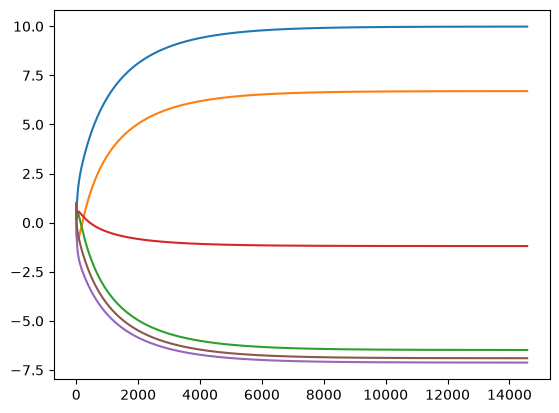

In [9]:
import matplotlib.pyplot as plt

for i in range(6):
    plt.plot(range(path.shape[0]), path[:,i])

For this estimate $\hat{\beta}$, we can compute the confusion matrix of the associated predictions:

In [10]:
logits = X @ beta_hat
y_hat = (logits > 0).astype(int)

from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true=y, y_pred=y_hat)
print(f'Confusion matrix:\n{matrix}')
print(f'Correctness rate = {100 * (matrix[0][0] + matrix[1][1]) / 50} %')

Confusion matrix:
[[ 21   4]
 [  3  22]]
Correctness rate = 86.0 %


Using the `LogisticRegression` model from `sklearn.linear_model` without regularisation, we obtain similar coefficient estimates:

In [11]:
from sklearn.linear_model import LogisticRegression

sklearn_model = LogisticRegression(fit_intercept=False, C=np.inf).fit(X, y)
print(sklearn_model.coef_)


[[ 9.987  6.7   -6.483 -1.191 -7.125 -6.902]]
